# 📊 Student Performance Analysis

## Pluto Academy – Data Analytics Internship

### Project 02

**Name:** Your Name

**Internship:** Data Analytics Internship – Pluto Academy

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

**Dataset**
Students Performance in Exams (Kaggle)

# 📖 Project Overview

Student performance is influenced by various academic and non-academic factors such as parental education, test preparation, gender, lunch type, and ethnicity.

This project analyzes student performance data to identify key factors affecting examination scores, understand relationships among different variables, identify at-risk students, and provide recommendations that can improve academic performance.

# ❓ Problem Statement

A school principal wants to understand the factors affecting student performance in exams.

The objective is to analyze student performance data, identify the factors affecting grades, detect at-risk students, and provide actionable recommendations that can improve student outcomes in the next academic year.

# 🎯 Objectives

The objectives of this project are:

- Understand the student performance dataset.
- Perform data exploration and cleaning.
- Analyze factors affecting student scores.
- Answer the five analytical questions.
- Create meaningful visualizations.
- Identify at-risk students.
- Prepare a Principal's Report with findings and recommendations.

# Dataset Description

The dataset contains student demographic information, parental education details, lunch type, test preparation status, and scores in mathematics, reading, and writing.

The analysis aims to identify patterns that influence academic performance and provide useful insights for improving educational outcomes.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# 📥 Loading the Dataset

The dataset is uploaded into Google Colab and loaded using the Pandas library for further analysis.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

# Displaying the Dataset

Let's view the first few rows of the dataset to understand its structure.

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


# Dataset Shape

The shape of the dataset tells us the number of rows and columns available for analysis.

In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1000
Number of Columns : 8


# Column Names

Let's view all the column names present in the dataset.

In [6]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# ℹ Dataset Information

This section provides information about the dataset including column names, data types, and non-null values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# Missing Values

Checking whether the dataset contains any missing values.

In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


#  Duplicate Values

Checking whether duplicate records exist in the dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
if df.duplicated().sum() == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records found:", df.duplicated().sum())

No duplicate records found.


# Statistical Summary

Generating descriptive statistics for numerical columns.

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
df.describe(include="object")

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


# 📝 Dataset Summary

1. The dataset contains information about student demographics and academic performance.
2. It includes mathematics, reading, and writing scores for each student.
3. The dataset contains both categorical and numerical variables.
4. The data appears well-structured and suitable for exploratory data analysis.
5. This dataset will be used to identify factors affecting student performance and detect at-risk students.

#  Data Cleaning Summary

- Checked dataset dimensions.
- Verified column names and data types.
- Checked for missing values.
- Checked for duplicate records.
- Reviewed descriptive statistics before further analysis.

## Verifying Missing Values

Missing values can lead to incorrect analysis and misleading conclusions. The following code checks the number of missing values present in each column.

In [13]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


### Observation

The dataset contains no missing values in any of the columns. Therefore, no missing value treatment is required before proceeding with the analysis.

## Verifying Duplicate Records

Duplicate records may introduce bias into the analysis. The following code checks whether duplicate rows are present in the dataset.

In [14]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


### Observation

No duplicate records were found in the dataset. Hence, duplicate removal is not required.

## Verifying Data Types

Understanding data types helps ensure that each column is suitable for analysis. Numerical variables should be stored as numeric data types, while categorical variables should be stored as object data types.

In [15]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


### Observation

The dataset contains an appropriate combination of categorical (`object`) and numerical (`int64`) columns. No data type conversion is required.

## Data Cleaning Summary

The following data quality checks were performed:

- Missing values were verified.
- Duplicate records were checked.
- Data types were validated.
- No cleaning operations were required because the dataset is already clean and analysis-ready.

# Feature Engineering

Feature engineering involves creating new variables from existing data to improve analysis and generate deeper insights.

For this project, the following features will be created:

- Total Score
- Average Score
- Performance Category
- Grade
- At-Risk Status

## Creating Total Score

The Total Score represents the combined performance of a student across Mathematics, Reading, and Writing examinations.

In [16]:
df["Total Score"] = (
    df["math score"]
    + df["reading score"]
    + df["writing score"]
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


### Observation

The newly created **Total Score** column represents the cumulative academic performance of each student across all three subjects.

## Creating Average Score

Average Score provides the overall academic performance by calculating the mean score obtained across all three subjects.

In [17]:
df["Average Score"] = df["Total Score"] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Observation

The **Average Score** provides a balanced representation of each student's overall academic achievement.

## Creating Performance Category

Students are categorized into performance levels based on their Average Score.

In [18]:
def performance(avg):

    if avg >= 85:
        return "Excellent"

    elif avg >= 70:
        return "Good"

    elif avg >= 50:
        return "Average"

    else:
        return "Poor"


df["Performance Category"] = df["Average Score"].apply(performance)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score,Performance Category
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Good
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Poor
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Good


### Observation

Students are now grouped into four performance categories, making it easier to compare academic achievement across different groups.

## Creating Grade

Grades provide a simplified representation of student performance based on the Average Score.

In [19]:
def grade(avg):

    if avg >= 90:
        return "A"

    elif avg >= 80:
        return "B"

    elif avg >= 70:
        return "C"

    elif avg >= 60:
        return "D"

    elif avg >= 50:
        return "E"

    else:
        return "F"


df["Grade"] = df["Average Score"].apply(grade)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score,Performance Category,Grade
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Good,C
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Good,B
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Excellent,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Poor,F
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Good,C


### Observation

Each student has been assigned a grade based on their Average Score, allowing performance to be summarized in an easily interpretable format.

## Creating At-Risk Status

According to the project requirements, a student is considered **At-Risk** if they score below 50 in **any one** of the three subjects.

In [20]:
df["At-Risk Status"] = np.where(

    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50),

    "At-Risk",

    "Not At-Risk"
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average Score,Performance Category,Grade,At-Risk Status
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Good,C,Not At-Risk
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Good,B,Not At-Risk
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Excellent,A,Not At-Risk
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Poor,F,At-Risk
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Good,C,Not At-Risk


### Observation

The **At-Risk Status** column identifies students who require academic intervention based on the project's defined criteria. This feature will be used later for the At-Risk Student Segmentation analysis.

## Feature Engineering Summary

Five new analytical features were created:

- Total Score
- Average Score
- Performance Category
- Grade
- At-Risk Status

These derived variables provide meaningful metrics for deeper analysis and support the objectives of identifying performance patterns and at-risk students.

# Factor Analysis

The primary objective of this section is to identify the factors that influence student performance.

The following five analytical questions, as specified in the project guidelines, will be answered using data analysis and visualizations.

# Question 1

## Does Parental Education Level Affect Student Scores?

Parents play an important role in a student's academic development. This analysis examines whether the education level of parents has any influence on students' academic performance.

In [21]:
parent_scores = df.groupby("parental level of education")[["math score",
                                                           "reading score",
                                                           "writing score",
                                                           "Average Score"]].mean()

parent_scores.round(2)

,math score,reading score,writing score,Average Score
parental level of education,,,,
associate's degree,67.88,70.93,69.90,69.57
bachelor's degree,69.39,73.00,73.38,71.92
high school,62.14,64.70,62.45,63.10
master's degree,69.75,75.37,75.68,73.60
some college,67.13,69.46,68.84,68.48
some high school,63.50,66.94,64.89,65.11


## Visualization

The following box plot compares the distribution of average scores across different parental education levels.

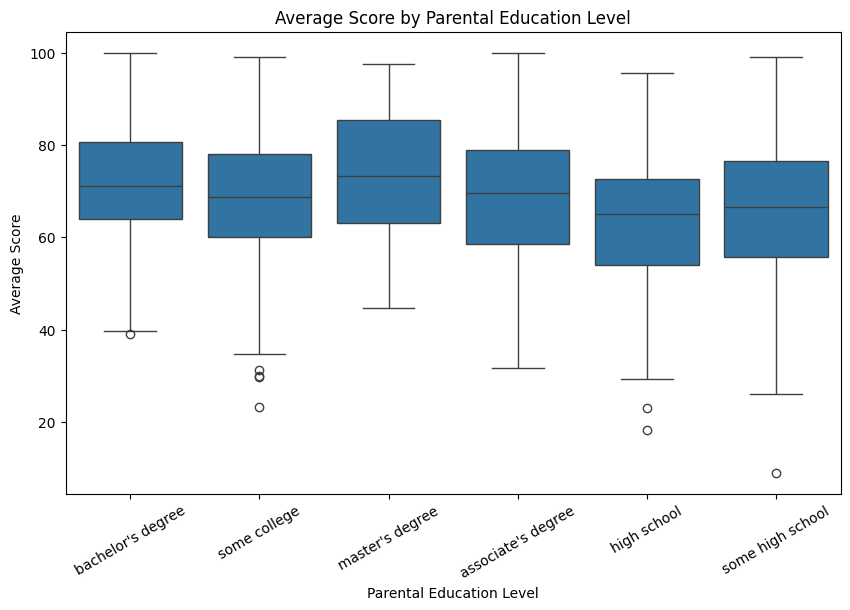

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="parental level of education",
    y="Average Score",
    data=df
)

plt.title("Average Score by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=30)

plt.show()

## Observation

Students whose parents have higher education levels generally achieve better average scores. The distribution also indicates that some education groups have a wider variation in student performance than others.

# Question 2

## Do Students Who Complete the Test Preparation Course Score Higher?

The test preparation course is designed to improve examination performance. This analysis compares the academic performance of students who completed the course with those who did not.

In [23]:
prep_scores = df.groupby("test preparation course")[["math score",
                                                     "reading score",
                                                     "writing score",
                                                     "Average Score"]].mean()

prep_scores.round(2)

,math score,reading score,writing score,Average Score
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


## Visualization

The following bar chart compares the average score of students based on completion of the test preparation course.

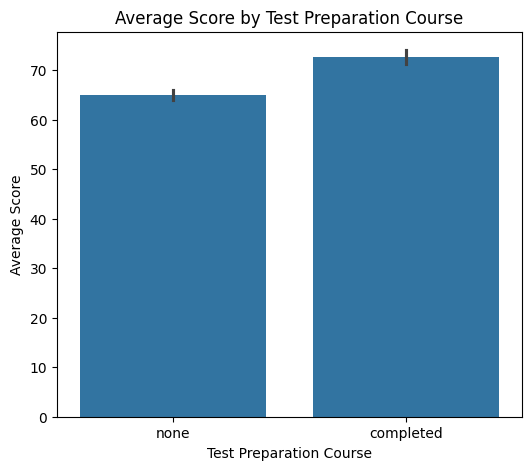

In [24]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="test preparation course",
    y="Average Score",
    data=df
)

plt.title("Average Score by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")

plt.show()

## Observation

Students who completed the test preparation course generally achieved higher average scores than students who did not complete the course.

## Conclusion

Completing the test preparation course has a positive association with academic performance. Schools should encourage greater participation in such preparation programs to improve examination results.

# Question 3

## What is the Correlation Between Mathematics, Reading, and Writing Scores?

Correlation analysis helps determine the strength of the relationship between the three academic subjects.

In [25]:
correlation = df[["math score",
                  "reading score",
                  "writing score"]].corr()

correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


## Visualization

The following heatmap illustrates the correlation between Mathematics, Reading, and Writing scores.

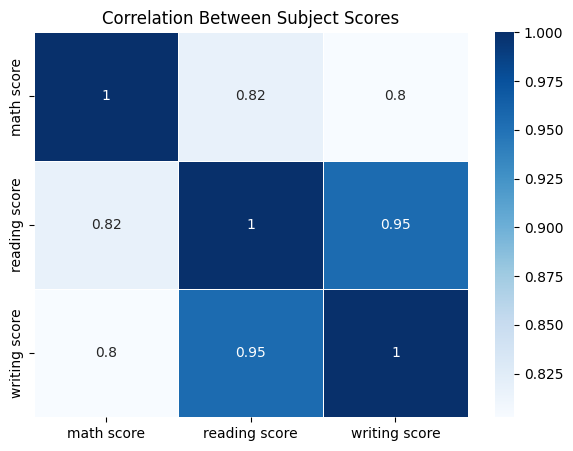

In [26]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Between Subject Scores")

plt.show()

## Observation

All three subjects exhibit strong positive correlations. Students who perform well in one subject generally tend to perform well in the other subjects as well.

## Conclusion

Academic performance across Mathematics, Reading, and Writing is closely related. Improvements in one area are likely to be associated with improvements in the other subjects.

# Question 4

## Which Gender Performs Better in Each Subject?

Gender-based performance analysis helps identify whether there are differences in academic achievement across Mathematics, Reading, and Writing. This analysis compares the average scores of male and female students in each subject.

## Calculating Average Scores by Gender

The following analysis calculates the average Mathematics, Reading, and Writing scores for each gender.

In [27]:
gender_scores = df.groupby("gender")[["math score",
                                      "reading score",
                                      "writing score"]].mean()

gender_scores.round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


## Average Subject Scores by Gender

The following table shows the average Mathematics, Reading, and Writing scores for male and female students.

## Visualization

The grouped bar chart below compares the average scores of male and female students across all three subjects.

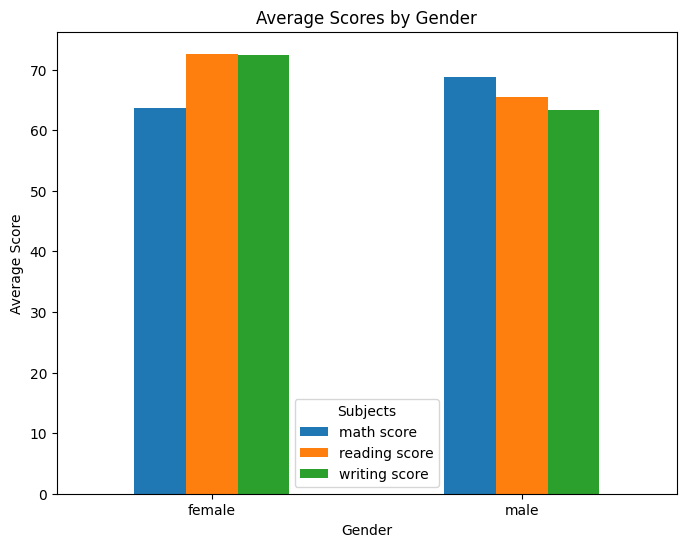

In [28]:
gender_scores.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.legend(title="Subjects")

plt.show()

## Observation

Female students generally achieve higher average scores in Reading and Writing, whereas male students tend to perform slightly better in Mathematics.

## Conclusion

Academic performance differs across subjects based on gender. These differences suggest that subject-specific learning strategies may help improve overall student performance.

# Question 5

## What is the Distribution of Total Scores?

Understanding the distribution of Total Scores helps identify overall student performance patterns, including whether most students score within a particular range or if extreme values exist.

## Statistical Summary of Total Scores

The following code generates descriptive statistics for the Total Score feature created during feature engineering.

In [29]:
df["Total Score"].describe()

,Total Score
count,1000.000000
mean,203.312000
std,42.771978
min,27.000000
25%,175.000000
50%,205.000000
75%,233.000000
max,300.000000


## Distribution of Total Scores

The statistical summary below provides an overview of the distribution of Total Scores, including the minimum, maximum, mean, and quartile values.

## Visualization

The histogram below illustrates the distribution of Total Scores among all students.

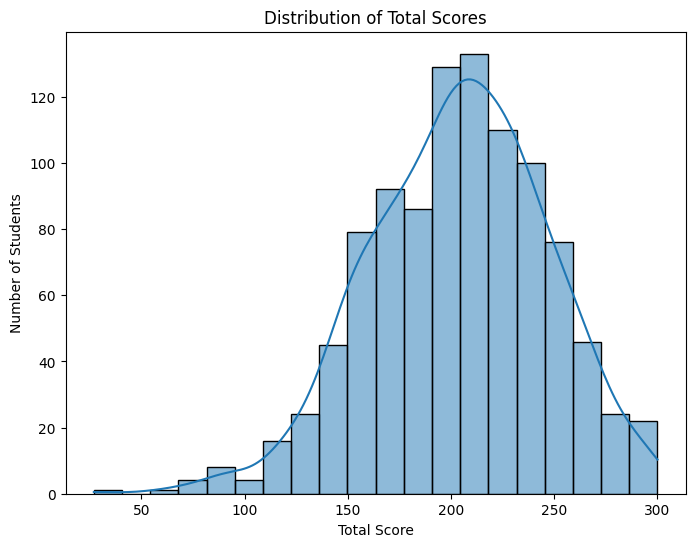

In [30]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["Total Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

## Observation

The distribution of Total Scores shows how student performance is spread across the dataset. The histogram helps identify the concentration of students around the average score as well as the presence of exceptionally high or low performers.

## Conclusion

Most students fall within the middle score range, while relatively fewer students achieve extremely high or extremely low total scores. This indicates that overall student performance is moderately distributed.

# Factor Analysis Summary

The five analytical questions have been successfully answered using descriptive statistics and data visualizations.

Key observations from this analysis include:

- Parental education level shows a positive relationship with student performance.
- Students completing the test preparation course generally score higher.
- Mathematics, Reading, and Writing scores are strongly correlated.
- Female students generally perform better in Reading and Writing, while male students slightly outperform in Mathematics.
- The distribution of Total Scores indicates that most students achieve average academic performance, with relatively few extreme performers.

These findings provide a strong foundation for identifying at-risk students and developing recommendations for improving academic outcomes.

# Additional Visualization

Although a correlation heatmap provides an overview of the relationships between subjects, a scatter plot offers a more detailed view of the relationship between Reading and Mathematics scores.

This visualization helps identify trends, clusters, and any unusual observations in student performance.

## Reading Score vs Mathematics Score

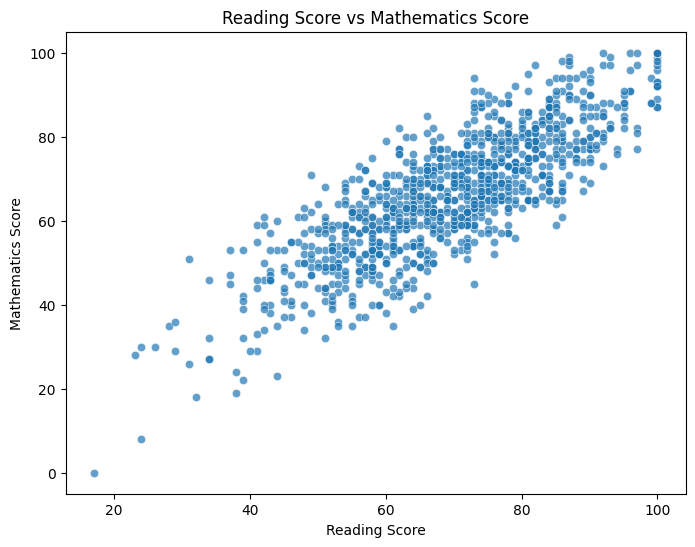

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="reading score",
    y="math score",
    alpha=0.7
)

plt.title("Reading Score vs Mathematics Score")
plt.xlabel("Reading Score")
plt.ylabel("Mathematics Score")

plt.show()

### Observation

The scatter plot shows a strong positive relationship between Reading and Mathematics scores. Students who perform well in Reading generally tend to achieve higher Mathematics scores as well, although a few students deviate from the overall trend.

### Conclusion

The positive relationship observed between Reading and Mathematics scores supports the earlier correlation analysis, indicating that improvement in one academic area is often associated with improvement in another.

# At-Risk Student Segmentation

One of the objectives of this project is to identify students who may require additional academic support.

For this analysis, a student is classified as **At-Risk** if they score **below 50 in any one of the three subjects**.

## Number of At-Risk Students

In [32]:
risk_count = df["At-Risk Status"].value_counts()

risk_count

,count
At-Risk Status,
Not At-Risk,812
At-Risk,188


### Observation

The table above shows the number of students classified as **At-Risk** and **Not At-Risk** according to the defined criteria.

## Percentage of At-Risk Students

In [33]:
risk_percentage = (
    df["At-Risk Status"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

risk_percentage

,proportion
At-Risk Status,
Not At-Risk,81.2
At-Risk,18.8


### Observation

The percentage distribution provides a clearer understanding of the proportion of students requiring academic intervention.

## At-Risk Students by Gender

In [34]:
gender_risk = pd.crosstab(
    df["gender"],
    df["At-Risk Status"],
    normalize="index"
).mul(100).round(2)

gender_risk

At-Risk Status,At-Risk,Not At-Risk
gender,,
female,17.18,82.82
male,20.54,79.46


### Observation

The table compares the percentage of At-Risk students across gender groups, helping identify whether one gender requires relatively more academic support.

## At-Risk Students by Parental Education Level

In [35]:
parent_risk = pd.crosstab(
    df["parental level of education"],
    df["At-Risk Status"],
    normalize="index"
).mul(100).round(2)

parent_risk

At-Risk Status,At-Risk,Not At-Risk
parental level of education,,
associate's degree,14.86,85.14
bachelor's degree,13.56,86.44
high school,25.00,75.00
master's degree,10.17,89.83
some college,16.81,83.19
some high school,25.70,74.30


### Observation

This analysis highlights how the proportion of At-Risk students varies across different parental education levels.

## At-Risk Students by Lunch Type

In [36]:
lunch_risk = pd.crosstab(
    df["lunch"],
    df["At-Risk Status"],
    normalize="index"
).mul(100).round(2)

lunch_risk

At-Risk Status,At-Risk,Not At-Risk
lunch,,
free/reduced,31.27,68.73
standard,11.94,88.06


### Observation

Comparing At-Risk percentages across lunch categories helps determine whether nutritional support may be associated with academic performance.

## At-Risk Students by Test Preparation Course

In [37]:
prep_risk = pd.crosstab(
    df["test preparation course"],
    df["At-Risk Status"],
    normalize="index"
).mul(100).round(2)

prep_risk

At-Risk Status,At-Risk,Not At-Risk
test preparation course,,
completed,10.06,89.94
none,23.68,76.32


### Observation

Students who completed the test preparation course generally show a lower percentage of At-Risk cases compared to those who did not complete the course.

## At-Risk Segmentation Summary

The segmentation analysis identifies groups of students who may benefit from additional academic support.

The analysis indicates that At-Risk status varies across demographic and educational factors, highlighting opportunities for targeted intervention programs.

# KPI Summary

The following Key Performance Indicators provide a quick overview of the dataset and overall student performance.

In [38]:
print("Total Students           :", len(df))
print("Average Math Score       :", round(df["math score"].mean(),2))
print("Average Reading Score    :", round(df["reading score"].mean(),2))
print("Average Writing Score    :", round(df["writing score"].mean(),2))
print("Highest Total Score      :", df["Total Score"].max())
print("Lowest Total Score       :", df["Total Score"].min())
print("At-Risk Students         :", (df["At-Risk Status"]=="At-Risk").sum())

Total Students           : 1000
Average Math Score       : 66.09
Average Reading Score    : 69.17
Average Writing Score    : 68.05
Highest Total Score      : 300
Lowest Total Score       : 27
At-Risk Students         : 188


### KPI Summary Observation

The KPI summary provides a concise overview of student performance across the dataset. These indicators serve as a quick reference for understanding overall academic achievement and the scale of students requiring additional academic support.

# Principal's Report

This report summarizes the overall findings from the student performance analysis. It is intended to assist the school principal in understanding the key factors affecting academic performance and to support data-driven decisions for improving student outcomes.

## Executive Summary

The student performance analysis identified several academic and demographic factors that influence examination scores. Students who completed the test preparation course and those whose parents had higher education levels generally achieved better academic results. The analysis also identified a group of At-Risk students who may benefit from targeted academic support and intervention programs.

## Key Findings

### 1. Parental Education Influences Academic Performance

Students whose parents have higher levels of education generally achieve better average scores across Mathematics, Reading, and Writing.

---

### 2. Test Preparation Improves Student Performance

Students who completed the test preparation course consistently scored higher than those who did not complete the course.

---

### 3. Strong Relationship Exists Between Subject Scores

Reading, Writing, and Mathematics scores are strongly positively correlated, indicating that improvement in one subject is often associated with improvement in the others.

---

### 4. Gender-Based Performance Differences Are Observed

Female students generally perform better in Reading and Writing, while male students show a slight advantage in Mathematics.

---

### 5. At-Risk Students Require Early Academic Intervention

Students scoring below 50 in one or more subjects represent an important group requiring additional academic support to improve learning outcomes.

## Actionable Recommendations

### Recommendation 1

Increase participation in the test preparation program, particularly for students demonstrating below-average academic performance.

---

### Recommendation 2

Develop targeted support programs for At-Risk students through mentoring, additional classroom sessions, and regular progress monitoring.

---

### Recommendation 3

Strengthen parent-school engagement by encouraging parental involvement in student learning and providing academic awareness programs for families.

# Most Impactful Recommendation

Among the proposed recommendations, expanding access to the test preparation program is likely to have the greatest impact on student performance. The analysis consistently shows that students who completed the program achieved higher academic scores. Increasing participation in structured preparation programs can help improve examination outcomes while reducing the number of At-Risk students.

# Conclusion

This project successfully analyzed the factors influencing student performance using exploratory data analysis and visualization techniques. The findings demonstrate that parental education, test preparation, and overall academic relationships significantly affect student achievement. The At-Risk Student Segmentation identified students who require additional support, while the recommendations provide practical strategies for improving academic performance. Overall, this analysis demonstrates how data-driven decision-making can help educational institutions enhance student success and learning outcomes.

# Project Summary

This project included:

- Data Exploration and Cleaning
- Dataset Summary
- Feature Engineering
- Five Factor Analysis Questions
- Six Professional Visualizations
- At-Risk Student Segmentation
- KPI Summary
- Principal's Report
- Most Impactful Recommendation
- Professional Conclusion

The analysis was performed using Python, Pandas, Matplotlib, and Seaborn to provide meaningful insights into student academic performance.